In [2]:
# Libraries Install
!pip install tensorflow
!pip install opencv-python

   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 1.8/350.9 MB 10.1 MB/s eta 0:00:35
   ---------------------------------------- 3.9/350.9 MB 10.2 MB/s eta 0:00:34
    --------------------------------------- 6.3/350.9 MB 10.4 MB/s eta 0:00:34
    --------------------------------------- 8.4/350.9 MB 10.4 MB/s eta 0:00:33
   - -------------------------------------- 10.2/350.9 MB 10.3 MB/s eta 0:00:34
   - -------------------------------------- 12.3/350.9 MB 10.2 MB/s eta 0:00:34
   - -------------------------------------- 14.4/350.9 MB 10.2 MB/s eta 0:00:34
   - -------------------------------------- 16.5/350.9 MB 10.1 MB/s eta 0:00:34
   -- ------------------------------------- 18.4/350.9 MB 10.0 MB/s eta 0:00:34
   -- ------------------------------------- 20.2/350.9 MB 9.8 MB/s eta 0:00:34
   -- ------------------------------------- 22.0/350.9 MB 9.7 MB/s eta 0:00:35
   -- ------------------------------------- 24.1/350.9 


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 3.4 MB/s eta 0:00:12
   - -------------------------------------- 1.6/40.2 MB 4.2 MB/s eta 0:00:10
   -- ------------------------------------- 2.9/40.2 MB 4.9 MB/s eta 0:00:08
   --- ------------------------------------ 3.9/40.2 MB 5.0 MB/s eta 0:00:08
   ---- ----------------------------------- 5.0/40.2 MB 5.0 MB/s eta 0:00:08
   ----- ---------------------------------- 5.5/40.2 MB 4.8 MB/s eta 0:00:08
   ------ --------------------------------- 6.6/40.2 MB 4.7 MB/s eta 0:00:08
   ------- -------------------------------- 7.6/40.2 MB 4.7 MB/s eta 0:00:07
   -------- ------------------------------- 8.7/40.2 MB 4.7 MB/s eta 0:00:07
   --------- ------------------------------ 9.4/40.2 MB 4.7 MB/s eta 0:00:07
   ---------- ----------------------------- 10.2/40.2 MB 4.6 MB/s eta 0:00:07
   ---------- ----------------------------- 11.0/40.2 MB 4.6 MB/s eta 0:00:07
   -


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
# Import Libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [15]:
# Image Parameters
img_size = 224
batch_size = 32

In [16]:
# Data Generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [17]:
# Load Dataset
train_data = train_datagen.flow_from_directory(
    "archive (4)/chest_xray/train",
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode='binary'
)

val_data = test_datagen.flow_from_directory(
    "archive (4)/chest_xray/val",
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [18]:
# Transfer Learning Model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [19]:
# Custom Layers
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128,activation='relu')(x)

output = Dense(1,activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [20]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train Model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
 15/163 ━━━━━━━━━━━━━━━━━━━━ 4:35 2s/step - accuracy: 0.9972 - loss: 0.0249

In [26]:
# Save Model
model.save("pneumonia_model.h5")

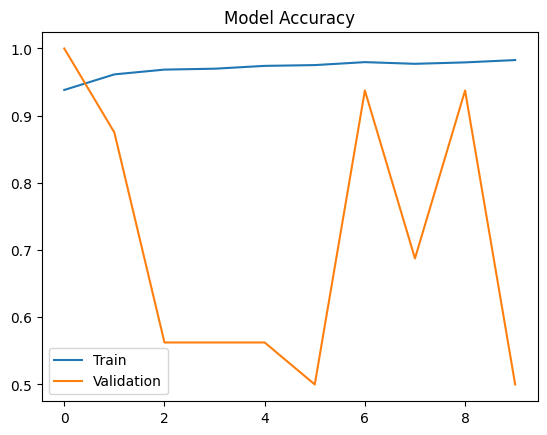

In [25]:
# Accuracy Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.legend(["Train","Validation"])

plt.show()